In [ ]:
import os

# Set your Kaggle API credentials
os.environ['KAGGLE_USERNAME'] = "aadya133"
os.environ['KAGGLE_KEY'] = "KGAT_aa53090173f88f269a35a819105c94eb"

# Now you can use Kaggle CLI commands directly
!kaggle datasets download -d jehanbhathena/weather-dataset


Dataset URL: https://www.kaggle.com/datasets/jehanbhathena/weather-dataset
License(s): CC0-1.0
100% 587M/587M [00:26<00:00, 23.4MB/s]



In [ ]:
!unzip weather-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: dataset/frost/3913.jpg  
  inflating: dataset/frost/3914.jpg  
  inflating: dataset/frost/3915.jpg  
  inflating: dataset/frost/3916.jpg  
  inflating: dataset/frost/3917.jpg  
  inflating: dataset/frost/3918.jpg  
  inflating: dataset/frost/3919.jpg  
  inflating: dataset/frost/3920.jpg  
  inflating: dataset/frost/3921.jpg  
  inflating: dataset/frost/3922.jpg  
  inflating: dataset/frost/3923.jpg  
  inflating: dataset/frost/3924.jpg  
  inflating: dataset/frost/3925.jpg  
  inflating: dataset/frost/3926.jpg  
  inflating: dataset/frost/3927.jpg  
  inflating: dataset/frost/3928.jpg  
  inflating: dataset/frost/3929.jpg  
  inflating: dataset/frost/3930.jpg  
  inflating: dataset/frost/3931.jpg  
  inflating: dataset/frost/3932.jpg  
  inflating: dataset/frost/3933.jpg  
  inflating: dataset/frost/3934.jpg  
  inflating: dataset/frost/3935.jpg  
  inflating: dataset/frost/3936.jpg  
  inflating: dataset/frost/3937.jpg  

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.utils import image_dataset_from_directory,plot_model
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
DATASET_PATH='dataset'
IMG_SIZE=(128,128)
BATCH_SIZE=32
EPOCHS=20

In [ ]:
train_ds=image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)
validation_ds=image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 6862 files belonging to 11 classes.
Using 5490 files for training.
Found 6862 files belonging to 11 classes.
Using 1372 files for validation.


In [ ]:
# Further split validation= val+test
val_batches=tf.data.experimental.cardinality(validation_ds)
test_ds=validation_ds.take(val_batches//2) #starting 50% in test
validation_ds=validation_ds.skip(val_batches//2)  # skip 50% => next 50% in validation

In [ ]:
class_names=train_ds.class_names
print("Classes: ",class_names)

Classes:  ['dew', 'fogsmog', 'frost', 'glaze', 'hail', 'lightning', 'rain', 'rainbow', 'rime', 'sandstorm', 'snow']


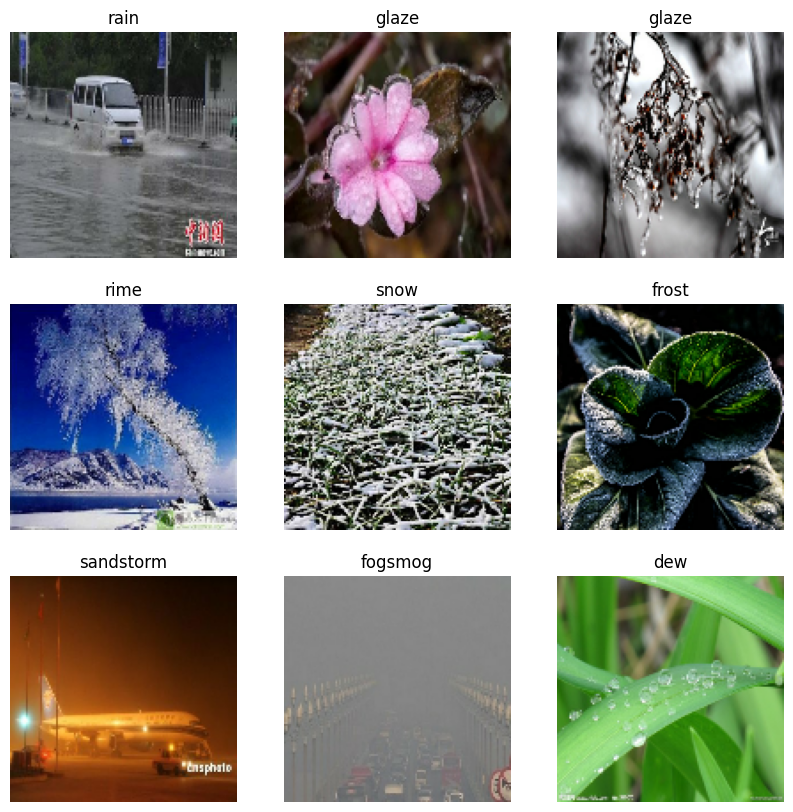

In [ ]:
plt.figure(figsize=(10,10))
for images,labels in train_ds.take(1):
    for i in range(9):
        ax=plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
# Class distribution
class_counts={}
for class_names in os.listdir(DATASET_PATH):
    class_counts[class_names]=len(os.listdir(os.path.join(DATASET_PATH,class_names)))
print(class_counts)

{'rainbow': 232, 'sandstorm': 692, 'frost': 475, 'dew': 698, 'fogsmog': 851, 'glaze': 639, 'rain': 526, 'snow': 621, 'lightning': 377, 'rime': 1160, 'hail': 591}


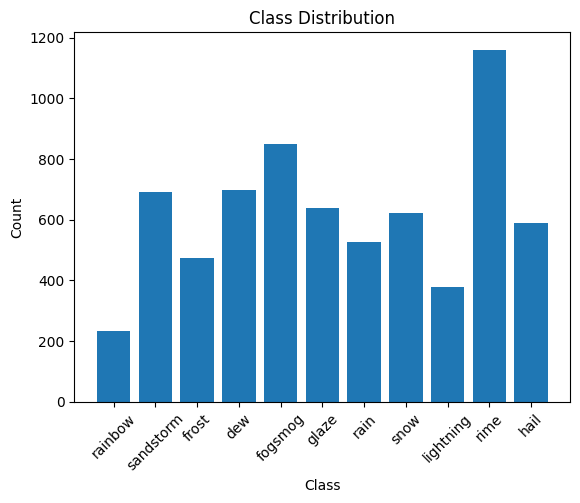

In [ ]:
plt.bar(class_counts.keys(),class_counts.values())
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

In [ ]:
# Normalization - add a layer of rescaling
normalization_layer=layers.Rescaling(1./255)
train_ds=train_ds.map(lambda x,y: (normalization_layer(x),y))
validation_ds=validation_ds.map(lambda x,y: (normalization_layer(x),y))
test_ds=test_ds.map(lambda x,y: (normalization_layer(x),y))

In [ ]:
# Performance Optimization
# Adding a cache for better performance
AUTOTUNE=tf.data.AUTOTUNE
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
validation_ds=validation_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds=test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
model=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(32,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5) ,# to prevent overfitting

    layers.Dense(len(class_names),activation='softmax')
])
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,852 (3.14 MB)

 Trainable params: 822,852 (3.14 MB)

 Non-trainable params: 0 (0.00 B)

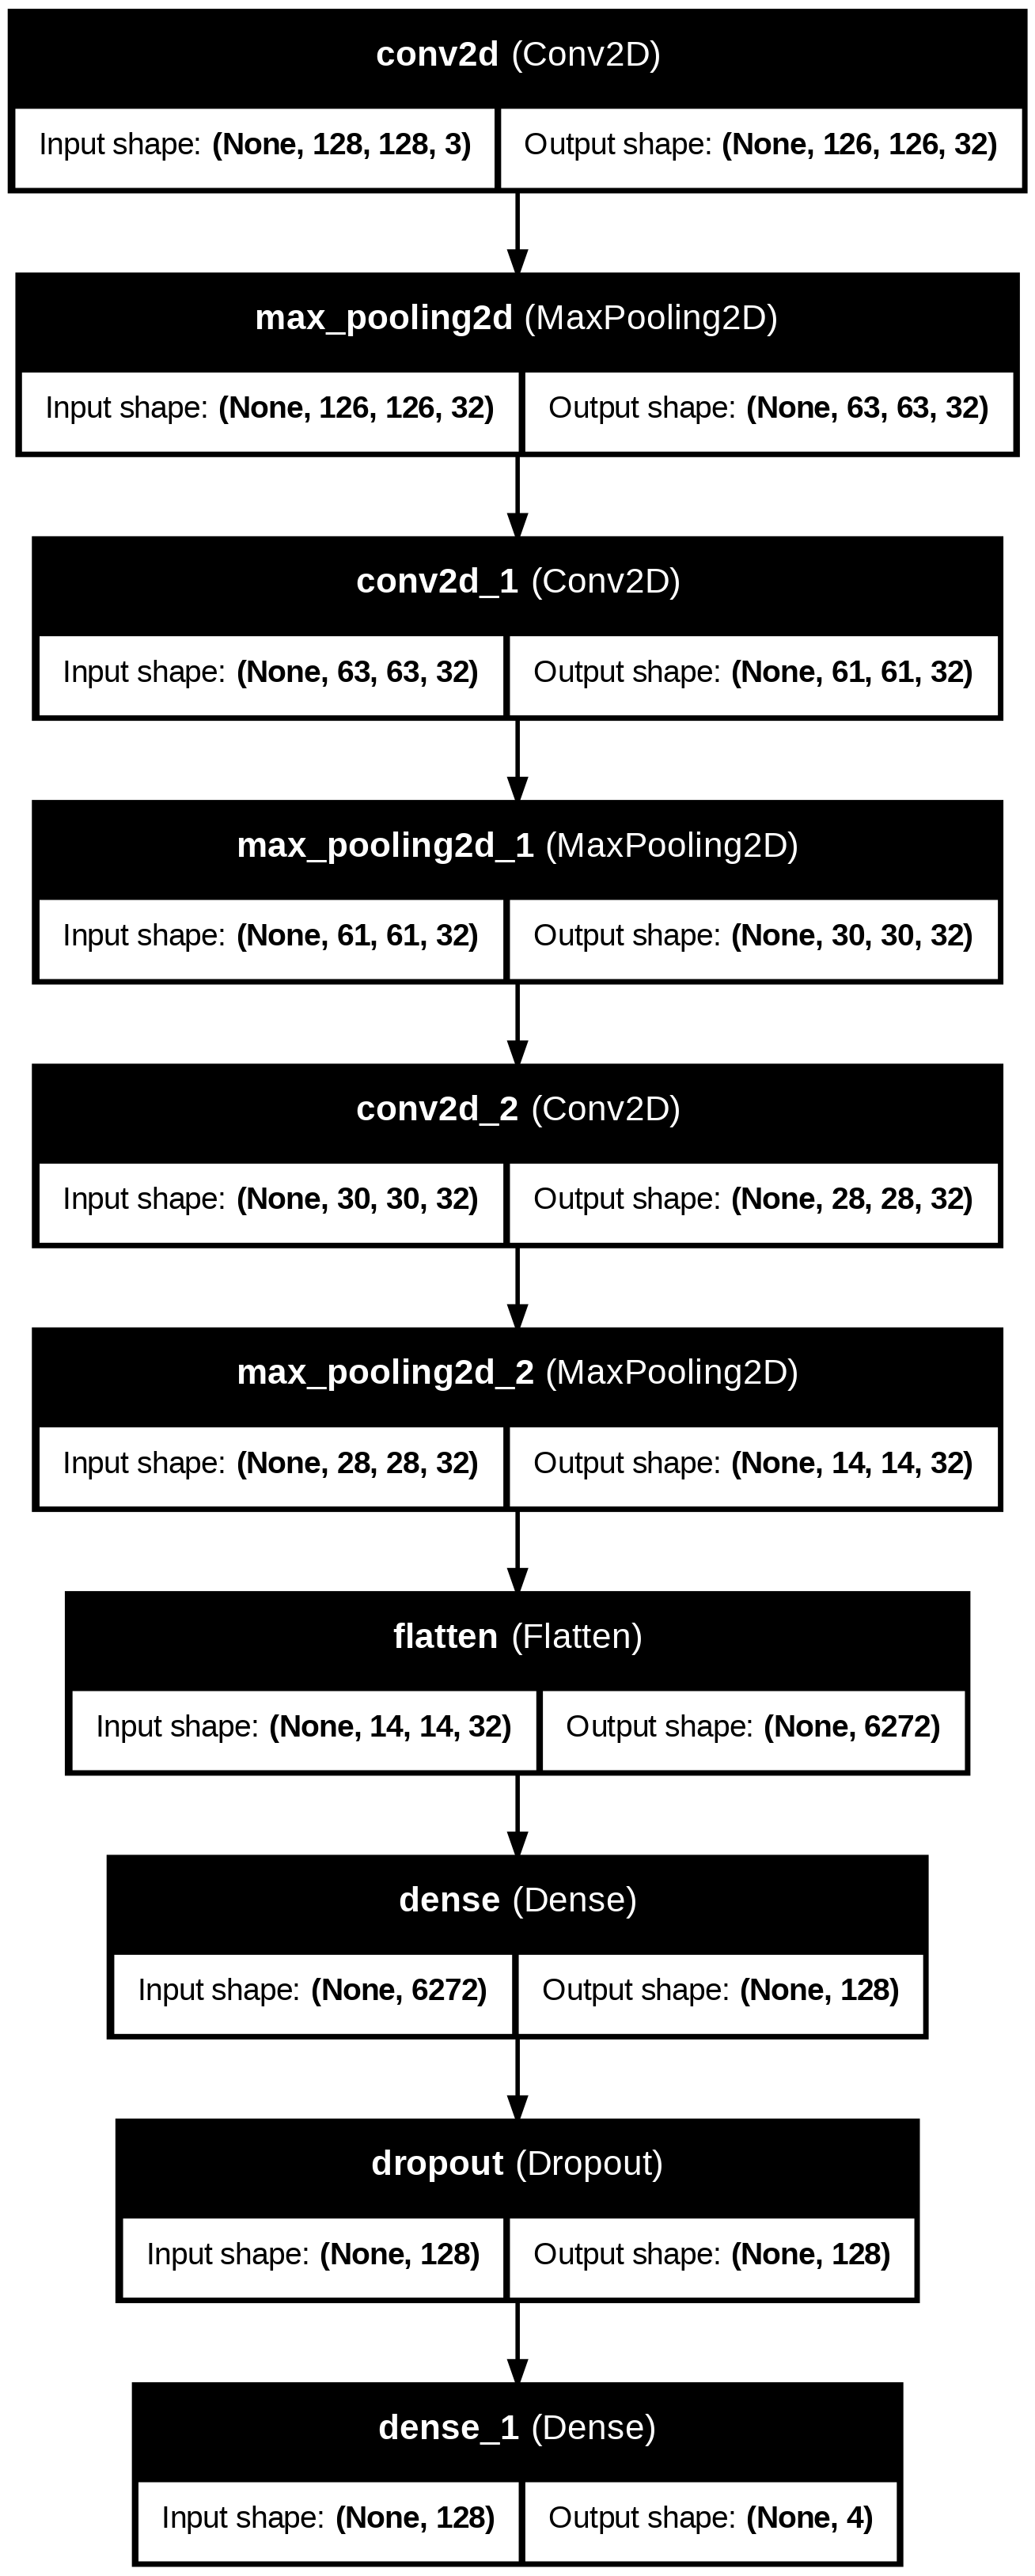

In [ ]:
plot_model(model,to_file='model_arch.png',show_shapes=True,show_layer_names=True)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history=model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=EPOCHS
)

Epoch 1/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.0920 - loss: nan - val_accuracy: 0.0948 - val_loss: nan
Epoch 2/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0914 - loss: nan - val_accuracy: 0.0948 - val_loss: nan
Epoch 3/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0914 - loss: nan - val_accuracy: 0.0948 - val_loss: nan
Epoch 4/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.0914 - loss: nan - val_accuracy: 0.0948 - val_loss: nan
Epoch 5/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0914 - loss: nan - val_accuracy: 0.0948 - val_loss: nan
Epoch 6/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0914 - loss: nan - val_accuracy: 0.0948 - val_loss: nan
Epoch 7/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.0914 - loss: nan - val_accuracy: 0.0948 - val_loss: nan
Epoch 8/20
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.0914 - loss: nan - val_accuracy: 0.0948 - val_loss: nan
Epoch 9/20
172/

In [ ]:
loss,acc=model.evaluate(test_ds)
print("Test Accuracy: ",acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.0881 - loss: nan
Test Accuracy:  0.08806817978620529


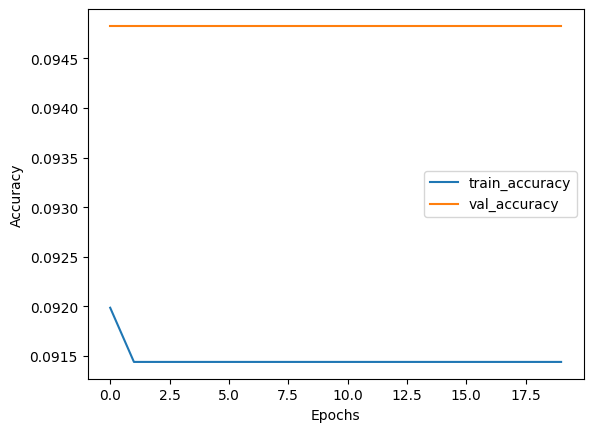

In [ ]:
# Plot model accuracy
plt.plot(history.history['accuracy'],label='train_accuracy')
plt.plot(history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()